### Importación de librerías

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns

### Lectura de Datos

In [124]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DIRECTORIO_DATOS_CRUDOS = f"{PATH_DIRECTORIO_DATOS }/raw"

In [125]:
PATH_DATASET_ORIGINAL = f"{PATH_DIRECTORIO_DATOS_CRUDOS}/dataset_practica_final.csv"

In [126]:
df_raw = pd.read_csv(PATH_DATASET_ORIGINAL) 

In [127]:
df_raw

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


### Comprobación y preprocesamiento de datos

In [128]:
#Mostrar las primeras filas del Dataframe
df_raw.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [129]:
#Mostrar las últimas filas del Dataframe
df_raw.tail(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119380,City Hotel,0,44,2017,August,35,31,1,3,2,...,No Deposit,9.0,NaN,0,Transient,140.75,0,1,Check-Out,2017-09-04
119381,City Hotel,0,188,2017,August,35,31,2,3,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,0,Check-Out,2017-09-05
119382,City Hotel,0,135,2017,August,35,30,2,4,3,...,No Deposit,7.0,NaN,0,Transient,209.00,0,0,Check-Out,2017-09-05
119383,City Hotel,0,164,2017,August,35,31,2,4,2,...,No Deposit,42.0,NaN,0,Transient,87.60,0,0,Check-Out,2017-09-06
119384,City Hotel,0,21,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,2,Check-Out,2017-09-06
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [130]:
# Mostrar las dimensiones del DataFrame
df_raw.shape

(119390, 32)

In [131]:
# Mostrar información del Dataframe

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [132]:
# Descripción estadística de las columnas numéricas

df_raw.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


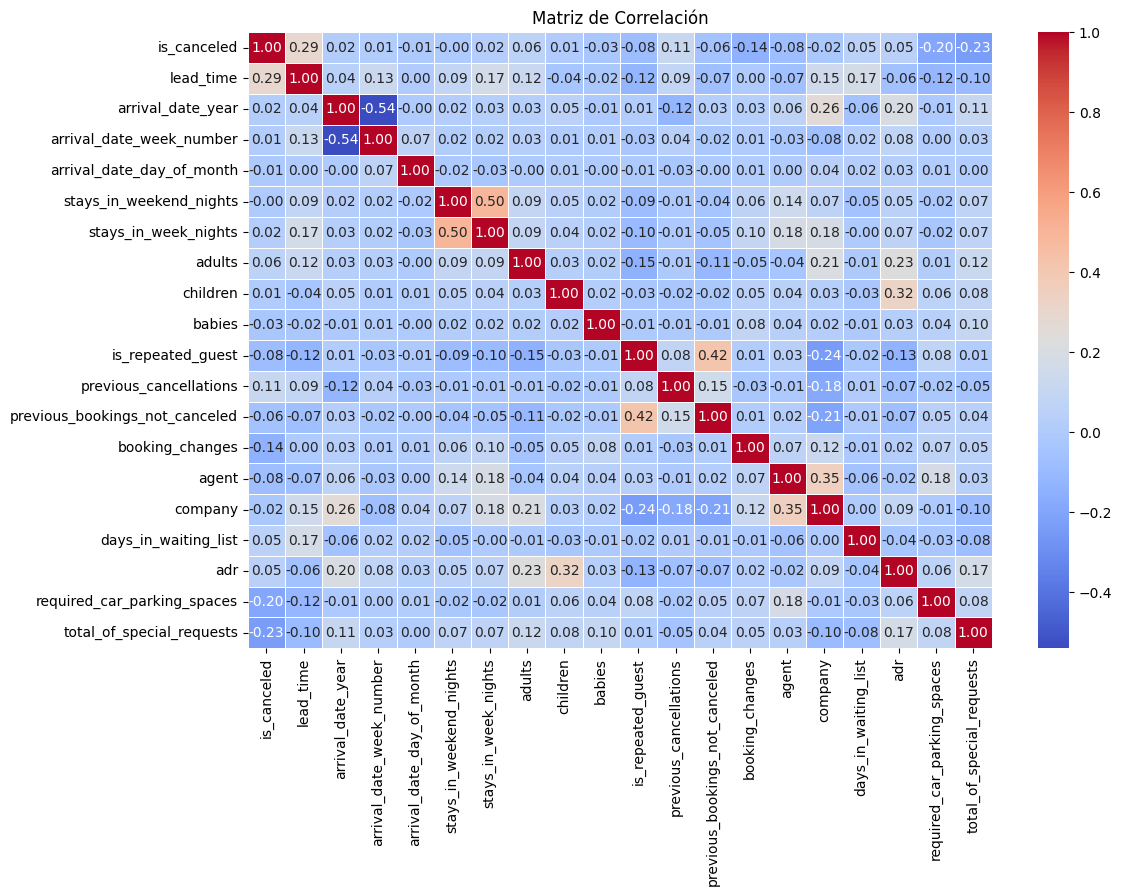

In [133]:
plt.figure(figsize=(12, 8))
columnas_numericas = df_raw.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_raw[columnas_numericas].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [134]:
#Se procederá a eliminar las columnas agent, company, reservation_status, reservation_status_date y arrival_date_year

#Las columnas agent y company contienen ID de agentes y el ID de compañia, los cuales vamos a considerarlos datos no pertinentes para la prediccion: Por una parte agent es un dato administrativo que no representa un comportamiento del cliente y que no aportaría valor al hacer una imputación de los valores nulos.Ademas que complicaría la aplicaciñon de técnicas como el one-hot encoding.De igual forma, company es un dato administrativo que no representa un comportamiento del cliente y además tiene más de 94% de valores nulos.

# La columna reservation_status indica como quedo el status final del cliente, que es precisamente lo que estamos tratando de predecir antes de que ocurra, por lo que en un escenario real es un dato que no se tendría al momento de hacer una predicción. Por este mismo argumento tambien eliminaremos la columna reservation_status_date.

# La columna arrival_date_year no aporta información para predecir comportamiento futuro de los clientes, en cambio sí es necesario contar con valores como días,meses y semanas del año para entender si la estacionalidad influye en la cancelación de las reservas.


df_preprocessed = df_raw.drop(columns=['agent', 'company', 'reservation_status', 'reservation_status_date', 'arrival_date_year'])

In [135]:
df_preprocessed

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,27,1,0,0,2,0.0,...,0,C,C,3,No Deposit,0,Transient,0.00,0,0
1,Resort Hotel,0,737,July,27,1,0,0,2,0.0,...,0,C,C,4,No Deposit,0,Transient,0.00,0,0
2,Resort Hotel,0,7,July,27,1,0,1,1,0.0,...,0,A,C,0,No Deposit,0,Transient,75.00,0,0
3,Resort Hotel,0,13,July,27,1,0,1,1,0.0,...,0,A,A,0,No Deposit,0,Transient,75.00,0,0
4,Resort Hotel,0,14,July,27,1,0,2,2,0.0,...,0,A,A,0,No Deposit,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,August,35,30,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,96.14,0,0
119386,City Hotel,0,102,August,35,31,2,5,3,0.0,...,0,E,E,0,No Deposit,0,Transient,225.43,0,2
119387,City Hotel,0,34,August,35,31,2,5,2,0.0,...,0,D,D,0,No Deposit,0,Transient,157.71,0,4
119388,City Hotel,0,109,August,35,31,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,104.40,0,0


In [ ]:
# En la descripción estadística se observó que existen valores negativos de adr, lo cual es incoherente porque representa el precio promedio diario. Procederemos a cuantificar las filas que tienen esa característica para tomar una decisión.


cantidad_negativos = (df_preprocessed['adr'] < 0).sum()

print(f"Cantidad de registros con adr negativo: {cantidad_negativos}")

Cantidad de registros con adr negativo: 1


In [144]:
# Ahora filtramos el dataframe para mantener solo valores mayores o iguales a 0. En este caso vamos a asumir que el 0 es un valor válido para el precio promedio por ejempo en casos como promociones o algún tipo de consideración especial.
df_preprocessed = df_preprocessed[df_preprocessed['adr'] >= 0]

# Verificamos el nuevo valor mínimo de la columna para asegurarnos que ya no está ese valor negativo y admás verificamos que la cantidad total de filas se redujo en 1.

print(f"Nuevo valor mínimo de ADR: {df_preprocessed['adr'].min()}")
print(f"Cantidad de filas y columnas: {df_preprocessed.shape}")

Nuevo valor mínimo de ADR: 0.0
Cantidad de filas y columnas: (119389, 27)


In [145]:
#A continuación vamos a deteminar la cantidad y procentaje de valores nulos existentes en este nuevo dataframe

cantidad_nulos = df_preprocessed.isnull().sum()
porcentaje_nulos = (df_preprocessed.isnull().sum() / len(df_preprocessed)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad Nulos': cantidad_nulos,
    'Porcentaje %': porcentaje_nulos
})

tabla_nulos.round(3)

,Cantidad Nulos,Porcentaje %
hotel,0,0.000
is_canceled,0,0.000
lead_time,0,0.000
arrival_date_month,0,0.000
arrival_date_week_number,0,0.000
arrival_date_day_of_month,0,0.000
stays_in_weekend_nights,0,0.000
stays_in_week_nights,0,0.000
adults,0,0.000
children,4,0.003


In [146]:
# Solamente hay valores nulos en la columna children (0.003%) y country (0.409%) por lo tanto al ser un porcentaje muy bajo con respecto al total de filas del dataframe se procederá a eliminar las filas que tienen esos valores nulos.

df_preprocessed = df_preprocessed.dropna(subset=['children', 'country'])

In [147]:
#Ahora obtenemos nuestro dataframe sin valores nulos

df_preprocessed

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,27,1,0,0,2,0.0,...,0,C,C,3,No Deposit,0,Transient,0.00,0,0
1,Resort Hotel,0,737,July,27,1,0,0,2,0.0,...,0,C,C,4,No Deposit,0,Transient,0.00,0,0
2,Resort Hotel,0,7,July,27,1,0,1,1,0.0,...,0,A,C,0,No Deposit,0,Transient,75.00,0,0
3,Resort Hotel,0,13,July,27,1,0,1,1,0.0,...,0,A,A,0,No Deposit,0,Transient,75.00,0,0
4,Resort Hotel,0,14,July,27,1,0,2,2,0.0,...,0,A,A,0,No Deposit,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,August,35,30,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,96.14,0,0
119386,City Hotel,0,102,August,35,31,2,5,3,0.0,...,0,E,E,0,No Deposit,0,Transient,225.43,0,2
119387,City Hotel,0,34,August,35,31,2,5,2,0.0,...,0,D,D,0,No Deposit,0,Transient,157.71,0,4
119388,City Hotel,0,109,August,35,31,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,104.40,0,0


In [148]:
# Ahora vamos a hacer una optimización del dataframe cambiando el tipo de dato de las columnas categóricas que son tipo Object a tipo Category
columnas_categoricas = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 
    'distribution_channel', 'reserved_room_type', 'assigned_room_type', 
    'deposit_type', 'customer_type'
]

for col in columnas_categoricas:
    df_preprocessed[col] = df_preprocessed[col].astype('category')

# Cambiamos el tipo de dato de la columna children de float64 a int64 ya que no es necesario guardar decimales para el número de niños.
df_preprocessed['children'] = df_preprocessed['children'].astype('int64')

# Verificar los cambios
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118897 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           118897 non-null  category
 1   is_canceled                     118897 non-null  int64   
 2   lead_time                       118897 non-null  int64   
 3   arrival_date_month              118897 non-null  category
 4   arrival_date_week_number        118897 non-null  int64   
 5   arrival_date_day_of_month       118897 non-null  int64   
 6   stays_in_weekend_nights         118897 non-null  int64   
 7   stays_in_week_nights            118897 non-null  int64   
 8   adults                          118897 non-null  int64   
 9   children                        118897 non-null  int64   
 10  babies                          118897 non-null  int64   
 11  meal                            118897 non-null  category
 12  country

### Gráficos y análisis de los datos

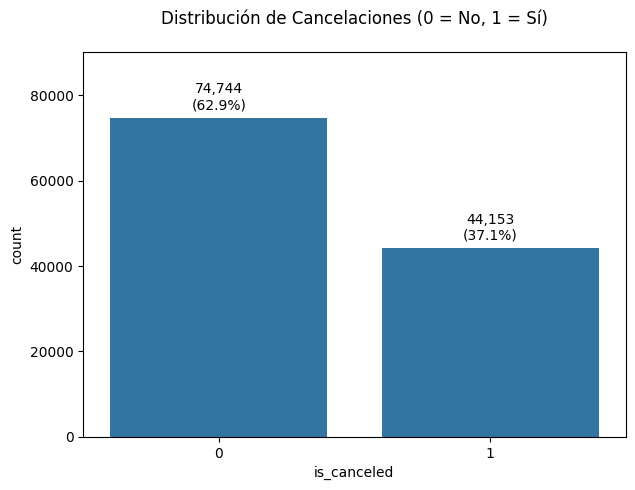

In [149]:
# Distribución de cancelaciones

# En el gráfico se observa un leve desbalanceo entra las clases con un 62.9% de clientes que no cancelaron y un 37.1% de clientes que sí lo hicieron.

plt.figure(figsize=(7, 5))


ax = sns.countplot(x='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)


for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    ax.bar_label(container, labels=etiquetas, padding=4)

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Distribución de Cancelaciones (0 = No, 1 = Sí)', pad=20)

plt.show()

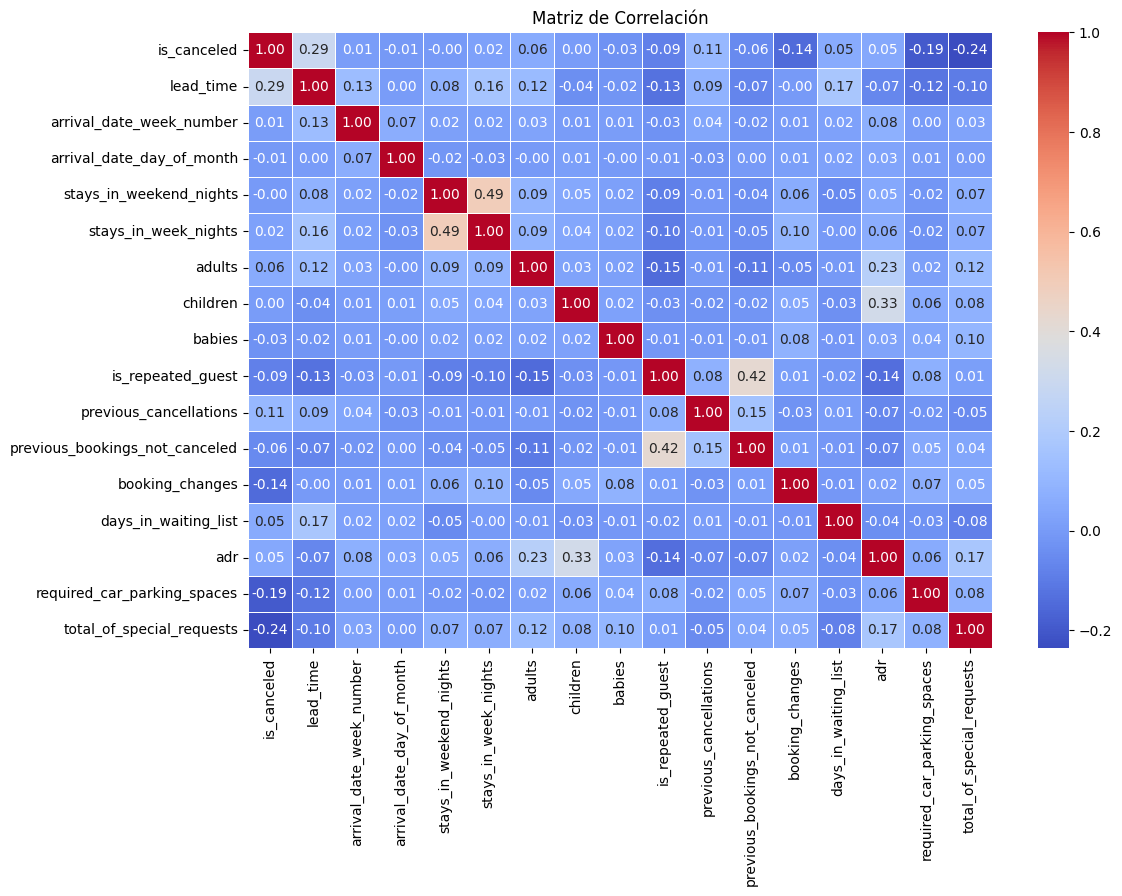

In [150]:
# Matriz de correlación

# Se observa que la variable que mas se correlaciona con la cancelación es el lead time. Por lo tanto la tendremos en cuenta para nuestros modelos y tambien realizaremos un box plot para evidencias de forma más detallada las tendencias y outliers.


plt.figure(figsize=(12, 8))
columnas_numericas = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_preprocessed[columnas_numericas].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

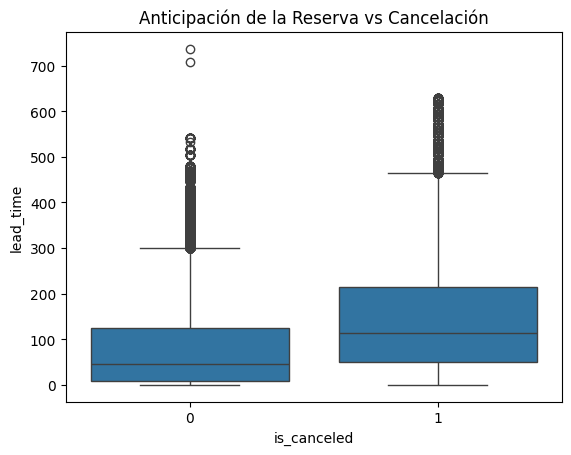

In [ ]:
# La anticipación de la reserva (lead_time) influye en la cancelación: En el box plot se aprecia una tendencia en la cual para las personas que no cancelaron la mediana es de 46 días, es decir la mitad de las personas que no cancelaron reservan como máximo con mes y medio de anticipación. Mientras que la mediana para las personas que cancelaron es de 113 dias.


sns.boxplot(x='is_canceled', y='lead_time', data=df_preprocessed)
plt.title('Anticipación de la Reserva vs Cancelación')
plt.show()

In [ ]:
# Aquí vemos la tabla exacta con los 5 números estadísticos del boxplot
df_preprocessed.groupby('is_canceled')['lead_time'].describe()[['min', '25%', '50%', '75%', 'max']].round(2)

,min,25%,50%,75%,max
is_canceled,,,,,
0,0.0,9.0,46.0,125.0,737.0
1,0.0,49.0,113.0,215.0,629.0


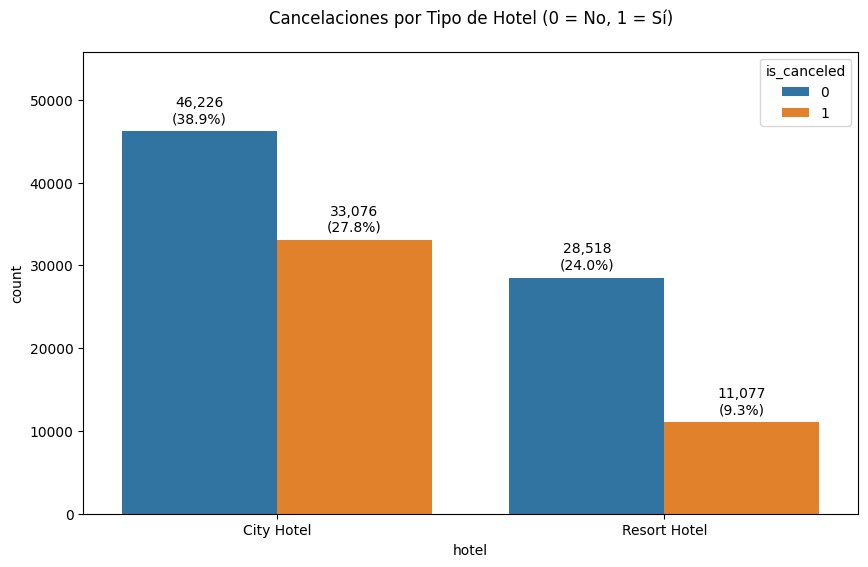

In [ ]:
# Cancelaciones por tipo de hotel

# Se observa que para los hoteles de tipo City Hotel aproximadamente el 41% de sus reservas son canceladas, mientras que para los Resort Hotel solamente 28% de los clientres cancelan.

# En términos absolutos tambien se observa una tendencia:las cancelaciones para hoteles tipo City hotel representan 27.8% de las reservaciones mientras que las del Resort Hotel son un 9.3% de las reservaciones.


plt.figure(figsize=(10, 6))

ax = sns.countplot(x='hotel', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Tipo de Hotel (0 = No, 1 = Sí)', pad = 20)
plt.show()

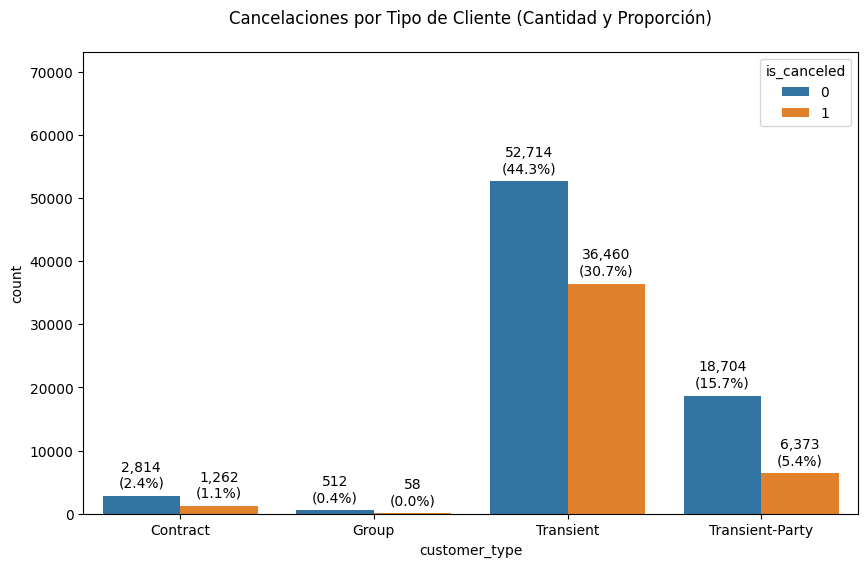

In [ ]:
# Cancelaciones por tipo de cliente

# El tipo de cliente Transient tiene más cancelaciones en proporción con respecto a los demás tipos.

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='customer_type', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Tipo de Cliente (Cantidad y Proporción)', pad = 20)
plt.show()

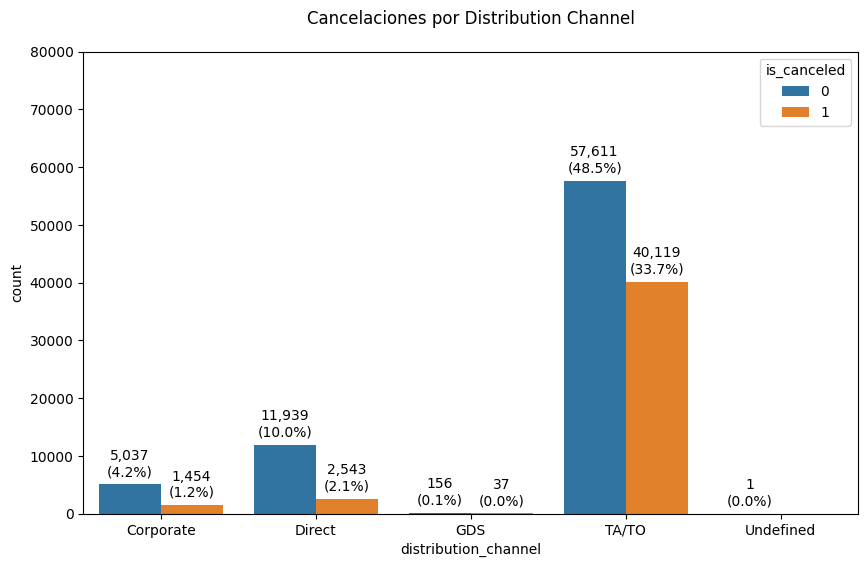

In [ ]:
# Cancelaciones por distribution channel

#El canal de distribución TA/TO concentra la mayor cantidad de cancelaciones tanto en términos absolutos como en proporcion de reservaciones aprobadas vs canceladas.


plt.figure(figsize=(10, 6))

ax = sns.countplot(x='distribution_channel', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Distribution Channel', pad = 20)
plt.show()

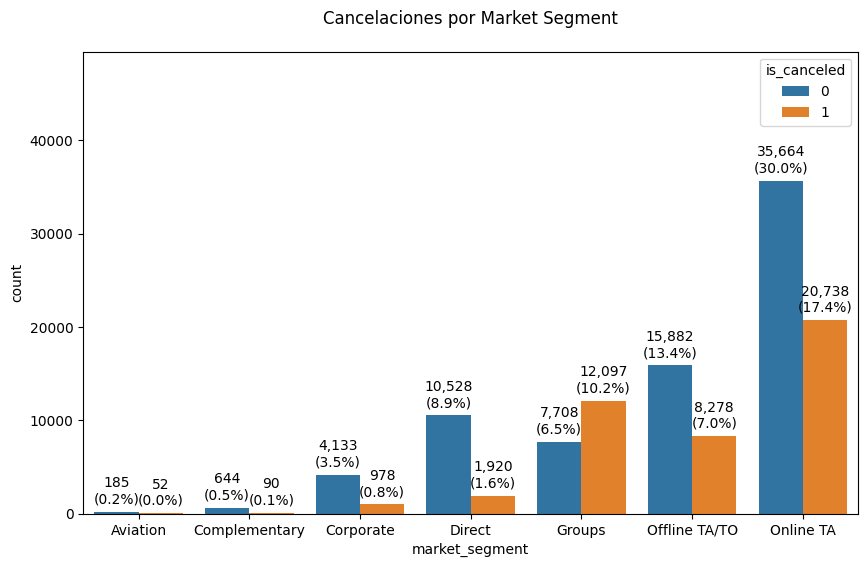

In [ ]:
# Cancelaciones por market segment

# En este caso destaca la categoría "Groups" que tiene un comportamiento distinto a las demás, con más usuarios que cancelaron que usuarios que no cancelaron. También se destaca que en términos absolutos la mayor cantidad de cancelaciones viene del grupo Online TA.

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='market_segment', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Market Segment', pad = 20)
plt.show()

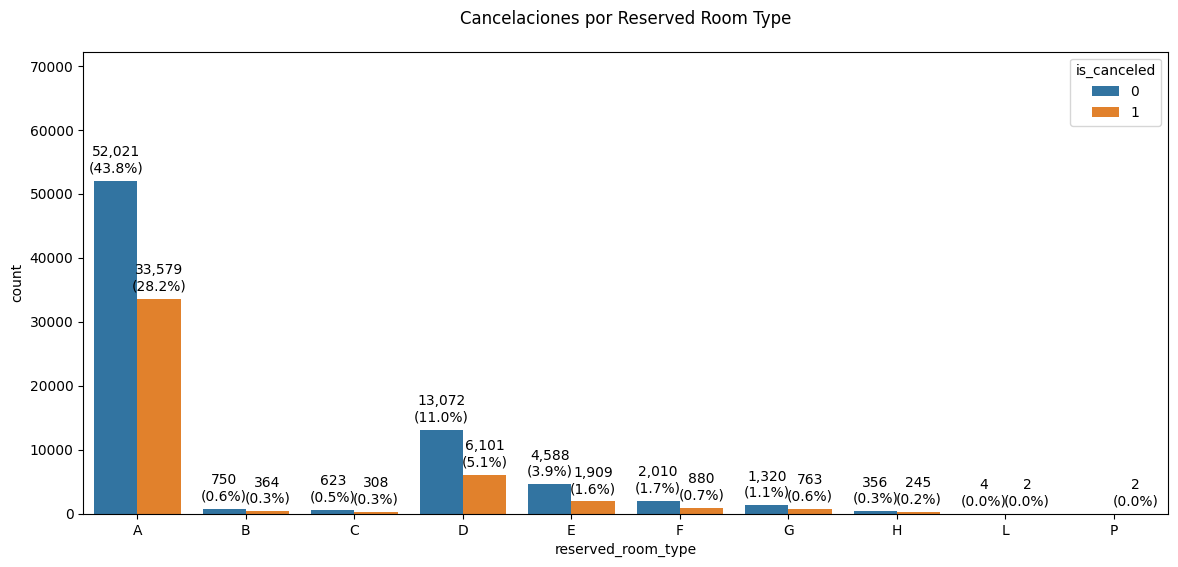

In [ ]:
#Cancelaciones por reserved_room_type

#En este gráfico se observa la tendencia mayoritaria de cancelaciones en el tipo de habitación A. Se destaca tambien el tipo de habitacion D que tambien tiene una mayor tendencia a la cancelación con respecto a los demás tipos de habitación.


plt.figure(figsize=(14, 6))

ax = sns.countplot(x='reserved_room_type', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Reserved Room Type', pad = 20)
plt.show()

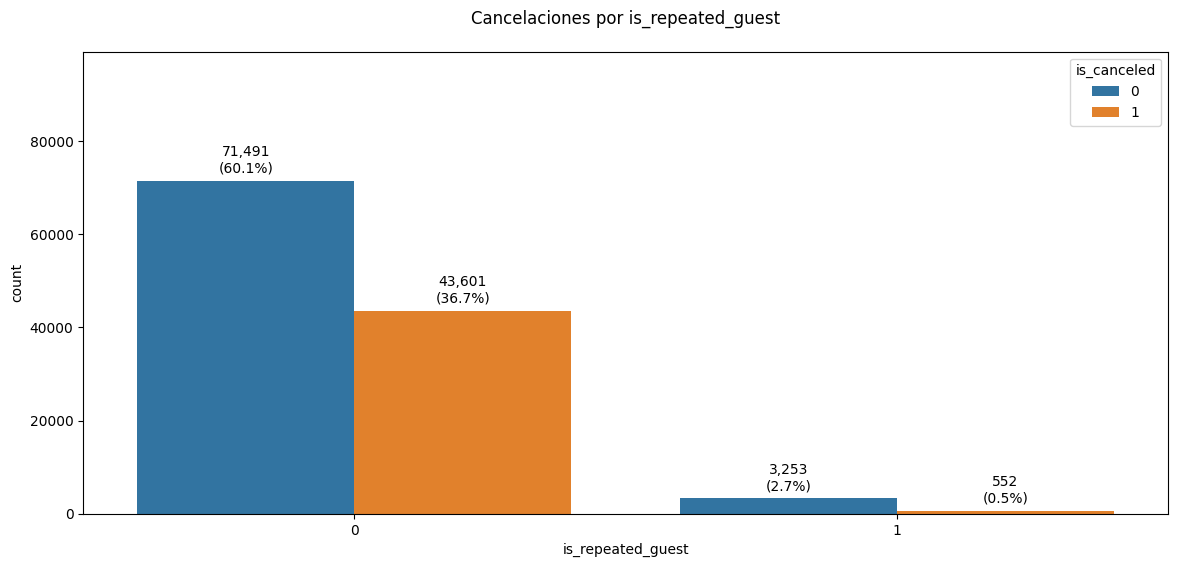

In [ ]:
#Cancelaciones por is_repeated_guest

# En este gráfico se ve la importancia de un programa de fidelidad, ya que los clientes recurrentes tienen menor probabilidad de cancelar sus reservaciones.


plt.figure(figsize=(14, 6))

ax = sns.countplot(x='is_repeated_guest', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por is_repeated_guest', pad = 20)
plt.show()

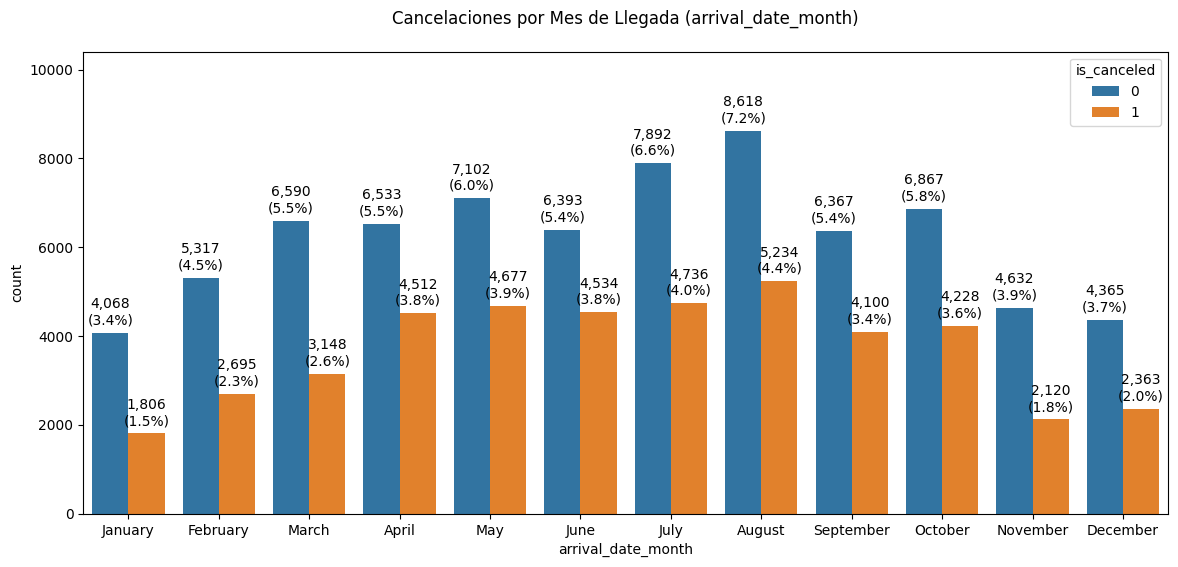

In [ ]:
# Cancelaciones por mes de llegada

# Se observa una mayor cantidad de reservaciones y cancelaciones en la época de primavera y verano.


plt.figure(figsize=(14, 6))

meses_ordenados = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

ax = sns.countplot(x='arrival_date_month', hue='is_canceled', data=df_preprocessed, order=meses_ordenados)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)


ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por Mes de Llegada (arrival_date_month)', pad=20)
plt.show()

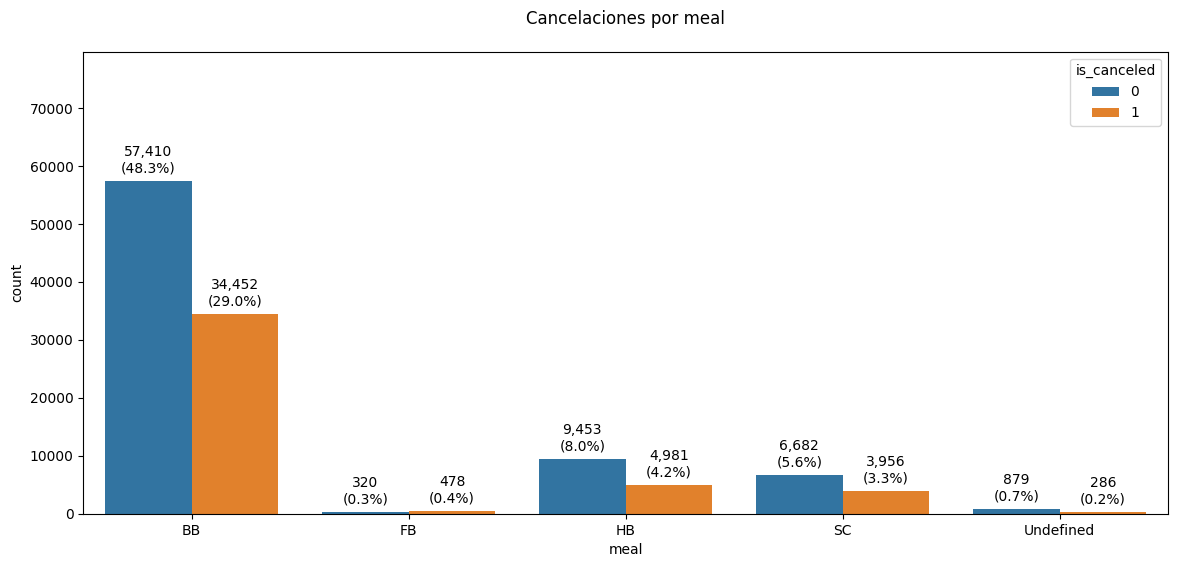

In [ ]:
# Cancelaciones por meal

#En este caso el mayor volumen de reservaciones y cancelaciones proviene de la categoria BB, sin embargo en términos proporcionales es llamativo el caso de la categoría FB que tiene más cancelaciones que reservas concretadas.


plt.figure(figsize=(14, 6))

ax = sns.countplot(x='meal', hue='is_canceled', data=df_preprocessed)

total_datos = len(df_preprocessed)

for container in ax.containers:
    etiquetas = [
        f'{int(v.get_height()):,}\n({v.get_height() / total_datos:.1%})' 
        if v.get_height() > 0 else '' 
        for v in container
    ]
    
    ax.bar_label(container, labels=etiquetas, label_type='edge', padding=4)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.title('Cancelaciones por meal', pad = 20)
plt.show()

### Exportación de datos preprocesados a formato .csv

In [ ]:
# El dataframe preprocesado se exporta al directorio data/processed para su uso en el entrenamiento de los modelos.


df_preprocessed.to_csv('../../data/processed/dataset_practica_final_preprocessed.csv', index=False, encoding='utf-8')